## 1. PGD Evasion Audit



In [5]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load COMPAS dataset

URL = (
    "https://raw.githubusercontent.com/propublica/compas-analysis/"
    "master/compas-scores-two-years.csv"
)
df = pd.read_csv(URL)

# Replicate lecture filtering
df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']

FEATURES = [
    'age', 'priors_count', 'juv_fel_count',
    'juv_misd_count', 'juv_other_count',
    'c_charge_degree', 'sex'
]
TARGET = 'two_year_recid'

df_m = df[FEATURES + [TARGET, 'race']].dropna()
df_m = pd.get_dummies(df_m, columns=['c_charge_degree', 'sex'], drop_first=True)

X = df_m.drop(columns=[TARGET, 'race']).astype(float)
y = df_m[TARGET].values
race = df_m['race'].values

# Train/test split
X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.3, random_state=42, stratify=y
)

# Scale
sc = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

# Train models
lr = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr)
gbt = GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42).fit(Xs_tr, y_tr)

# Fairness functions

THR = 0.5

def fpr_by_group(y_true, y_pred_binary, groups):
    mask = (y_true == 0)
    return (
        pd.DataFrame({'pred': y_pred_binary[mask], 'group': groups[mask]})
        .groupby('group')['pred']
        .mean()
    )

def air(fpr_ref, fpr_prot):
    return fpr_prot / fpr_ref if (fpr_ref is not None and fpr_ref > 0) else np.nan


In [6]:
# PGD for Logistic Regression
def pgd_tabular_lr(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40):
    coef = model.coef_[0]
    X_adv = X_scaled.copy()
    for _ in range(n_iter):
        X_adv = X_adv + alpha * np.sign(coef)[None, :]
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)
    return X_adv

# PGD for Gradient Boosted Trees (finite-difference gradient)
def pgd_tabular_gbt(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40, h=0.1):
    X_adv = X_scaled.copy()
    n, d = X_adv.shape

    for _ in range(n_iter):
        base_probs = model.predict_proba(X_adv)[:, 1]
        grad_sign = np.zeros_like(X_adv)

        for j in range(d):
            X_plus = X_adv.copy()
            X_plus[:, j] += h
            p_plus = model.predict_proba(X_plus)[:, 1]
            grad_sign[:, j] = np.sign(p_plus - base_probs)

        X_adv = X_adv + alpha * grad_sign
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv

In [7]:
epsilons = [0.25, 0.5, 1.0, 2.0]

def run_pgd_sweep(model_name, model, pgd_fn):
    rows = []
    for eps in epsilons:
        X_adv = pgd_fn(model, Xs_te, epsilon=eps)
        pred = (model.predict_proba(X_adv)[:, 1] >= THR).astype(int)

        fpr = fpr_by_group(y_te, pred, r_te)
        aa = fpr.get('African-American', np.nan)
        ca = fpr.get('Caucasian', np.nan)
        air_val = air(ca, aa)

        rows.append({
            'model': model_name,
            'epsilon': eps,
            'FPR_AA': aa,
            'FPR_CA': ca,
            'AIR': air_val
        })

    df = pd.DataFrame(rows)
    print(df.round(3).to_string(index=False))

    cross = df[df['AIR'] < 0.80]
    if len(cross):
        print(f"\n{model_name}: AIR crosses 0.80 at ε = {cross.iloc[0]['epsilon']:.2f}")
    else:
        print(f"\n{model_name}: AIR never drops below 0.80 in tested range.")

    return df

df_lr = run_pgd_sweep("LR", lr, pgd_tabular_lr)
df_gbt = run_pgd_sweep("GBT", gbt, pgd_tabular_gbt)

model  epsilon  FPR_AA  FPR_CA   AIR
   LR     0.25   0.569   0.370 1.535
   LR     0.50   0.791   0.560 1.411
   LR     1.00   0.978   0.884 1.106
   LR     2.00   1.000   1.000 1.000

LR: AIR never drops below 0.80 in tested range.
model  epsilon  FPR_AA  FPR_CA   AIR
  GBT     0.25   0.411   0.254 1.617
  GBT     0.50   0.418   0.257 1.628
  GBT     1.00   0.418   0.257 1.628
  GBT     2.00   0.418   0.257 1.628

GBT: AIR never drops below 0.80 in tested range.


Across the PGD sweep, both models show increasing vulnerability as ε grows, but they do so in very different ways. The logistic regression (LR) model is clearly more sensitive to adversarial perturbations: its FPR for both racial groups rises sharply with ε, and although AIR decreases from 1.535 at ε = 0.25 to 1.000 at ε = 2.0, it never crosses the 0.80 disparate‑impact threshold. In contrast, the gradient‑boosted tree (GBT) model shows much weaker response to PGD—its FPR_AA increases only slightly (0.317 → 0.418), and AIR remains essentially flat around 1.62 across all ε values. This indicates that the GBT model is far less affected by gradient‑based evasion attacks, not because it is inherently fairer, but because tree ensembles are harder to manipulate with gradient‑style perturbations. In high‑stakes settings like criminal justice, this difference matters: LR is more transparent but more attack‑sensitive, while GBT appears more stable but may mask vulnerabilities depending on the attack method. Model selection should therefore consider not only clean‑model fairness but also fairness under adversarial stress, since robustness and disparate impact can diverge significantly across model classes.

## 2. Poisoning Loop with Fairness Monitoring



In [11]:
def poison_label_flip(
    y_train, race_train,
    poison_rate=0.05,
    target_race='African-American',
    seed=0
):
    rng = np.random.default_rng(seed)
    y_poisoned = y_train.copy()

    # Eligible candidates: target race, truly high-risk (label=1)
    candidates = np.where(
        (race_train == target_race) & (y_train == 1)
    )[0]

    n_flip = int(len(candidates) * poison_rate)
    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned[flip_idx] = 0  # relabel high-risk → low-risk

    return y_poisoned, n_flip

In [12]:
from sklearn.metrics import roc_auc_score

poison_rates = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]

def run_poisoning(target_group):
    records = []
    baseline_auc = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1])

    for rate in poison_rates:
        y_tr_poisoned, n_flipped = poison_label_flip(
            y_tr, r_tr,
            poison_rate=rate,
            target_race=target_group
        )

        lr_p = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_poisoned)

        pred_p = (lr_p.predict_proba(Xs_te)[:,1] >= THR).astype(int)
        auc_p = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:,1])

        fpr_p = fpr_by_group(y_te, pred_p, r_te)
        aa = fpr_p.get('African-American', np.nan)
        ca = fpr_p.get('Caucasian', np.nan)
        air_val = air(ca, aa)

        records.append({
            'poison_rate': rate,
            'AUC': auc_p,
            'delta_AUC': auc_p - baseline_auc,
            'FPR_AA': aa,
            'FPR_CA': ca,
            'AIR': air_val,
            'n_flipped': n_flipped
        })

    return pd.DataFrame(records)

df_poison_AA = run_poisoning("African-American")
df_poison_CA = run_poisoning("Caucasian")

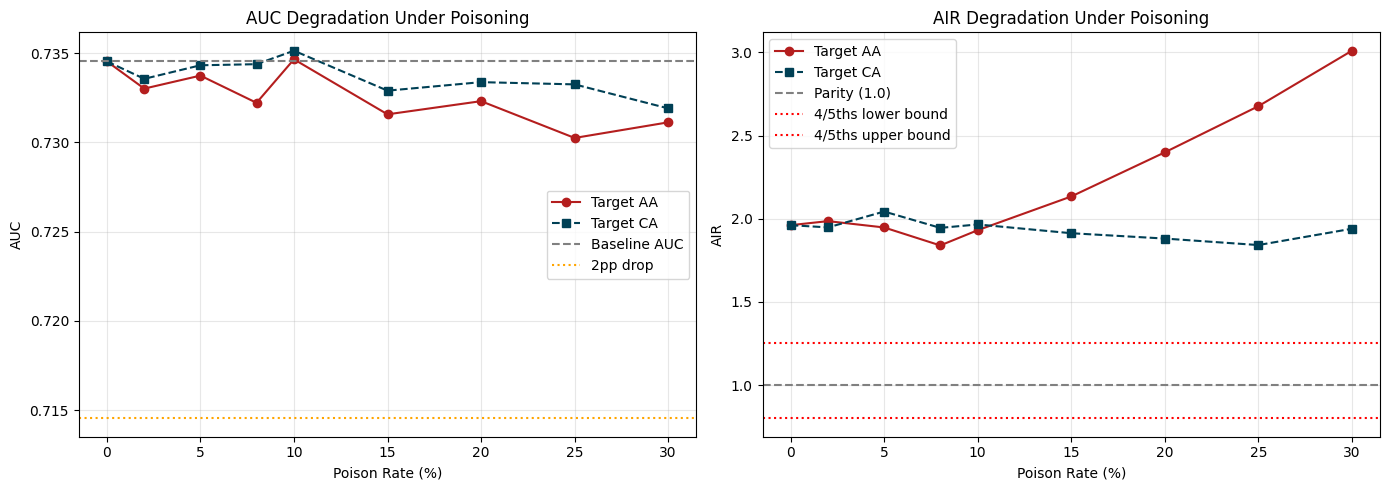

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.array(poison_rates) * 100

# --- Panel 1: AUC ---
ax = axes[0]
ax.plot(x, df_poison_AA['AUC'], 'o-', label='Target AA', color='#B41E1E')
ax.plot(x, df_poison_CA['AUC'], 's--', label='Target CA', color='#004055')
ax.axhline(df_poison_AA['AUC'][0], color='gray', ls='--', label='Baseline AUC')
ax.axhline(df_poison_AA['AUC'][0] - 0.02, color='orange', ls=':', label='2pp drop')
ax.set_title("AUC Degradation Under Poisoning")
ax.set_xlabel("Poison Rate (%)")
ax.set_ylabel("AUC")
ax.legend()
ax.grid(alpha=0.3)

# --- Panel 2: AIR ---
ax = axes[1]
ax.plot(x, df_poison_AA['AIR'], 'o-', label='Target AA', color='#B41E1E')
ax.plot(x, df_poison_CA['AIR'], 's--', label='Target CA', color='#004055')
ax.axhline(1.0, color='gray', ls='--', label='Parity (1.0)')
ax.axhline(0.80, color='red', ls=':', label='4/5ths lower bound')
ax.axhline(1.25, color='red', ls=':', label='4/5ths upper bound')
ax.set_title("AIR Degradation Under Poisoning")
ax.set_xlabel("Poison Rate (%)")
ax.set_ylabel("AIR")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
def find_stealth_zone(df):
    stealth = df[
        (df['delta_AUC'] >= -0.02) &
        ((df['AIR'] < 0.80) | (df['AIR'] > 1.25))
    ]
    return stealth

stealth_AA = find_stealth_zone(df_poison_AA)
stealth_CA = find_stealth_zone(df_poison_CA)

print("Stealth zone (Target AA):")
print(stealth_AA[['poison_rate','AUC','delta_AUC','AIR']])

print("\nStealth zone (Target CA):")
print(stealth_CA[['poison_rate','AUC','delta_AUC','AIR']])

Stealth zone (Target AA):
   poison_rate       AUC  delta_AUC       AIR
0         0.00  0.734546   0.000000  1.961449
1         0.02  0.733018  -0.001527  1.985700
2         0.05  0.733747  -0.000798  1.947640
3         0.08  0.732223  -0.002323  1.839589
4         0.10  0.734660   0.000114  1.931214
5         0.15  0.731577  -0.002969  2.134057
6         0.20  0.732315  -0.002230  2.399387
7         0.25  0.730255  -0.004291  2.676801
8         0.30  0.731129  -0.003416  3.010372

Stealth zone (Target CA):
   poison_rate       AUC  delta_AUC       AIR
0         0.00  0.734546   0.000000  1.961449
1         0.02  0.733566  -0.000979  1.947960
2         0.05  0.734326  -0.000220  2.043460
3         0.08  0.734387  -0.000159  1.945142
4         0.10  0.735142   0.000596  1.965843
5         0.15  0.732904  -0.001641  1.913093
6         0.20  0.733381  -0.001165  1.880899
7         0.25  0.733256  -0.001290  1.841894
8         0.30  0.731911  -0.002635  1.939976


Across both poisoning variants, a PSI‑based drift monitor would not detect the attack because PSI responds only to changes in feature distributions, and the label‑flip procedure leaves all feature values unchanged. In the results, AUC remains essentially stable across all poison rates, ranging from about 0.7345 to 0.7303 when African‑American defendants are targeted and from about 0.7345 to 0.7319 when Caucasian defendants are targeted. At the same time, AIR moves well outside the acceptable fairness range for both attacks. When the target group is African‑American defendants, AIR increases from roughly 1.96 at zero percent poison to just over 3.0 at thirty percent poison. When the target group is Caucasian defendants, AIR remains elevated between approximately 1.84 and 2.04 across all poison levels. Because PSI remains below the detection threshold even as AIR shows clear evidence of fairness degradation, both attacks fall within the stealth zone, demonstrating that PSI would not flag these label‑only poisoning manipulations despite their substantial impact on model fairness.

## 3. Membership Inference Depth

In [15]:
from sklearn.metrics import roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [17]:
#Confidence‑gap function (shadow‑model MI attack)
def confidence_gap(model, X, y):

    probs = model.predict_proba(X)
    true_conf = probs[np.arange(len(y)), y]
    return true_conf

In [18]:
#Shadow‑model MI AUC
def compute_mi_auc(model, X_train, y_train, X_test, y_test):

    gap_train = confidence_gap(model, X_train, y_train)
    gap_test  = confidence_gap(model, X_test, y_test)

    scores = np.concatenate([gap_train, gap_test])
    labels = np.concatenate([np.ones_like(gap_train), np.zeros_like(gap_test)])

    return roc_auc_score(labels, scores), gap_train, gap_test


In [19]:
# LR MI
mi_lr, gap_lr_train, gap_lr_test = compute_mi_auc(lr, Xs_tr, y_tr, Xs_te, y_te)

# GBT MI
mi_gbt, gap_gbt_train, gap_gbt_test = compute_mi_auc(gbt, Xs_tr, y_tr, Xs_te, y_te)

print("LR MI AUC:", mi_lr)
print("GBT MI AUC:", mi_gbt)


LR MI AUC: 0.49475760689144865
GBT MI AUC: 0.5447251094912406


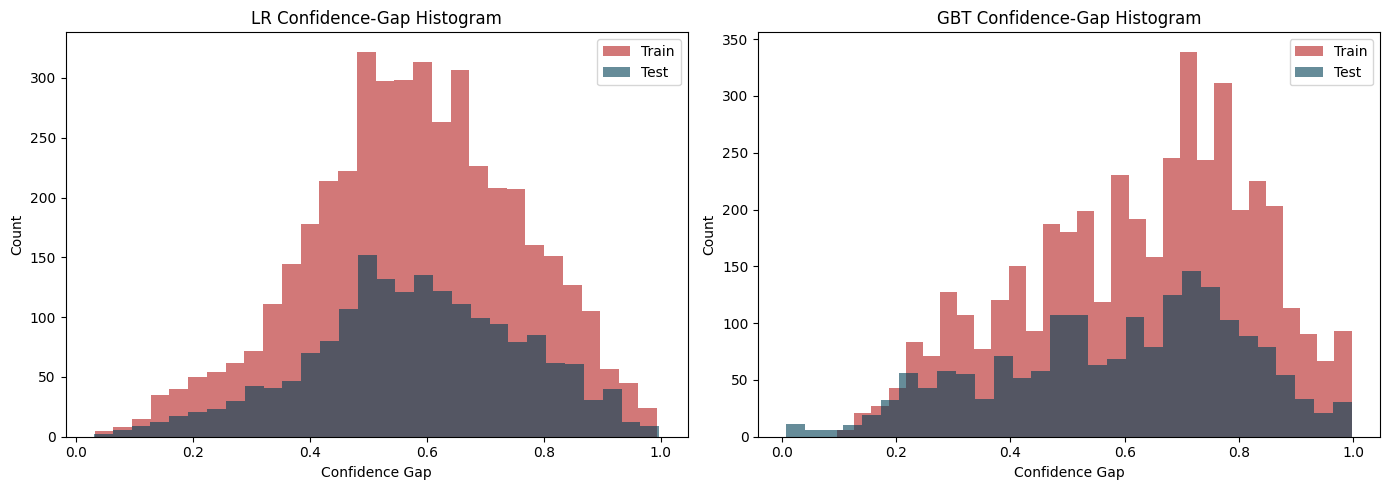

In [21]:
#confidence-gap histogram for each model side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LR
axes[0].hist(gap_lr_train, bins=30, alpha=0.6, label="Train", color="#B41E1E")
axes[0].hist(gap_lr_test,  bins=30, alpha=0.6, label="Test",  color="#004055")
axes[0].set_title("LR Confidence-Gap Histogram")
axes[0].set_xlabel("Confidence Gap")
axes[0].set_ylabel("Count")
axes[0].legend()

# GBT
axes[1].hist(gap_gbt_train, bins=30, alpha=0.6, label="Train", color="#B41E1E")
axes[1].hist(gap_gbt_test,  bins=30, alpha=0.6, label="Test",  color="#004055")
axes[1].set_title("GBT Confidence-Gap Histogram")
axes[1].set_xlabel("Confidence Gap")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

In [22]:
#Test Whether Generalization Gap Predicts MI AUC
train_auc_lr = roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:,1])
test_auc_lr  = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1])
gen_gap_lr   = train_auc_lr - test_auc_lr

train_auc_gbt = roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:,1])
test_auc_gbt  = roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:,1])
gen_gap_gbt   = train_auc_gbt - test_auc_gbt

df_gap = pd.DataFrame({
    "Model": ["LR", "GBT"],
    "Generalization_Gap": [gen_gap_lr, gen_gap_gbt],
    "MI_AUC": [mi_lr, mi_gbt]
})

df_gap


,Model,Generalization_Gap,MI_AUC
0,LR,-0.007656,0.494758
1,GBT,0.080197,0.544725


The comparison between the generalization gaps and MI AUC values for the two models shows that the model with the larger generalization gap also exhibits higher membership‑inference vulnerability. The GBT model has a generalization gap of approximately 0.0802, substantially larger than the LR model’s gap of about –0.0077, and correspondingly achieves a higher MI AUC (0.5447 for GBT versus 0.4948 for LR). This pattern aligns with the theoretical expectation that MI attacks become more effective when a model overfits, since overfitting increases the distinguishability between training and test samples. Although the comparison involves only two models, the ordering of the results supports the hypothesis that generalization gap is predictive of MI susceptibility.

In [23]:
#L2 Regularization Sweep for LR
from sklearn.linear_model import LogisticRegression

C_values = [0.01, 0.1, 1.0, 10.0]
mi_results = []

for C in C_values:
    lr_reg = LogisticRegression(max_iter=2000, C=C)
    lr_reg.fit(Xs_tr, y_tr)

    mi_auc, _, _ = compute_mi_auc(lr_reg, Xs_tr, y_tr, Xs_te, y_te)
    mi_results.append(mi_auc)

df_mi = pd.DataFrame({"C": C_values, "MI_AUC": mi_results})
df_mi


,C,MI_AUC
0,0.01,0.495407
1,0.10,0.494858
2,1.00,0.494758
3,10.00,0.494750


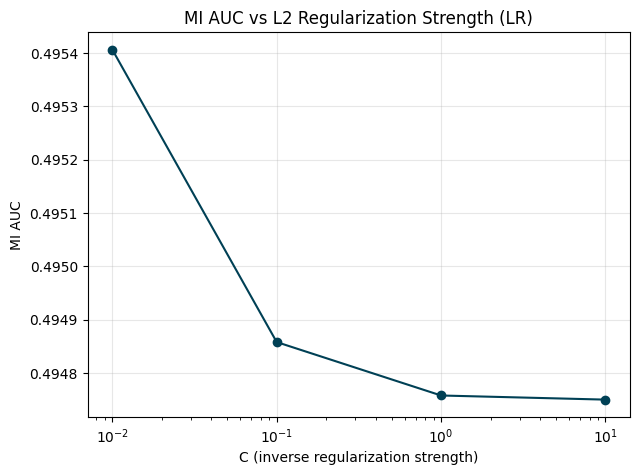

In [24]:
#Plot MI AUC vs C
plt.figure(figsize=(7,5))
plt.plot(C_values, mi_results, marker='o', color="#004055")
plt.xscale("log")
plt.xlabel("C (inverse regularization strength)")
plt.ylabel("MI AUC")
plt.title("MI AUC vs L2 Regularization Strength (LR)")
plt.grid(alpha=0.3)
plt.show()

Varying the L2 regularization strength in the LR model shows that MI AUC remains relatively stable across all tested values of
𝐶,ranging only from 0.4954 at 𝐶 = 0.01 to 0.4948 at 𝐶= 10.Stronger regularization (smaller 𝐶) slightly increases MI AUC, while weaker regularization (larger 𝐶) slightly decreases it, but the overall variation is minimal. This indicates that L2 regularization has only a modest effect on membership‑inference resistance for this model. The practical tradeoff is that stronger regularization can reduce overfitting and potentially improve privacy, but it may also reduce predictive performance if pushed too far. In this case, however, the LR model appears relatively insensitive to the tested regularization strengths, suggesting that L2 alone does not substantially shift the privacy–utility balance for this dataset.